
# 🧠 Keras Recurrent Neural Network

---


## 🎯 Objectius

* Aquest notebook pretén mostrar un exemple de Xarxa Neuronal Recurrent per rel tractament de dades seqüencials.
* La tasca consisteix en la predicció d'accions d'Apple de l'any 2025


## 📦 Datasets

En aquest notebook utilitzarem un dataset del valor de les accions de l'empresa Apple mitjançant l'API de Yahoo Finance.

![Yahoo Finance](https://play-lh.googleusercontent.com/jQVXIz4MbsuOJSzoeFsTeL2gHoaZTlBtz2JbyG9JAuhsrTPB2vSvsRqsINWYVUr3Xw=s64-rw)
![Yahoo Finance](https://files.softicons.com/download/system-icons/apple-logo-icons-by-thvg/png/64/Apple%20logo%20icon%20-%20Classic.png)

El dataset està descarregat en un fitxer CSV que conté els valors de les accions de cada dis des del 01/01/2020 fins el 31/12/2024

In [ ]:
#!pip install tensorflow


## 🟦 0. Descàrrega del dataset de Yahoo Finance

Descàrreguem el dataset de Yahoo Finance.

In [ ]:
import yfinance as yf

EMPRESA = "AAPL"

# Descarreguem el valor de les accions d'Apple entre els anys 2020-2024
data = yf.download(EMPRESA, start="2020-01-01", end="2025-12-31")
data = data[["Close"]]  #Agafem només les dades de tancament.

data.columns = [EMPRESA]
data.to_csv("nvidia_close_2020_2025.csv")

/tmp/ipython-input-338/4076592120.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(EMPRESA, start="2020-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1507 entries, 2020-01-02 to 2025-12-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NVDA    1507 non-null   float64
dtypes: float64(1)
memory usage: 23.5 KB


In [ ]:
import pandas as pd
df = pd.read_csv(
    "nvidia_close_2020_2025.csv",
    index_col=0,
    parse_dates=True
)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1507 entries, 2020-01-02 to 2025-12-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NVDA    1507 non-null   float64
dtypes: float64(1)
memory usage: 23.5 KB


,NVDA
Date,
2020-01-02,5.971078
2020-01-03,5.875504
2020-01-06,5.900145
2020-01-07,5.971576
2020-01-08,5.982776


## 🟦 0. Import Classes

In [ ]:
import yfinance as yf
import numpy as np
import math
from math import sqrt
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping


## 🟦 1. Load Dataset

Carreguem les dades i les normalitzem

## 🟦 2. Train Test Split

In [ ]:
# Split temporal explícit:
train_data = data.loc["2020-01-01":"2024-12-31"].copy()
test_data  = data.loc["2025-01-01":"2025-12-31"].copy()

In [ ]:
# Normalitzem les dades amb un Min Max
# Prem fit només a Train perquè no cauren en fuga de dades (data leakage)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data[[EMPRESA]])
test_scaled =  scaler.transform(test_data[[EMPRESA]])

train_data[EMPRESA+"_scaled"] = train_scaled
test_data[EMPRESA+"_scaled"] = test_scaled
#


In [ ]:
train_data.head()

,NVDA,NVDA_scaled
Date,,
2020-01-02,5.971078,0.007503
2020-01-03,5.875504,0.006839
2020-01-06,5.900145,0.007010
2020-01-07,5.971576,0.007507
2020-01-08,5.982776,0.007584


In [ ]:
# -------------------------
# 3) Funció per crear finestres (X, y) i dates de y
# -------------------------
def create_dataset_with_dates(df_scaled, col, look_back=60):
    """
    df_scaled: DataFrame amb columna col i index de dates
    Retorna:
      X: (samples, look_back)
      y: (samples,)
      y_dates: dates corresponents a cada y
    """
    values = df_scaled[col].values
    dates = df_scaled.index

    X, y, y_dates = [], [], []
    for i in range(look_back, len(values)):
        X.append(values[i - look_back:i])
        y.append(values[i])
        y_dates.append(dates[i])
    return np.array(X), np.array(y), np.array(y_dates)

# Train windows (només dins train)
look_back = 60
X_train, y_train, train_dates = create_dataset_with_dates(train_data, EMPRESA+"_scaled", look_back)



In [ ]:
X_train[:2]

array([[0.00750316, 0.00683916, 0.00701035, 0.00750662, 0.00758443,
        0.00804092, 0.0082657 , 0.00959022, 0.00877754, 0.00848184,
        0.00906282, 0.00912335, 0.00889165, 0.00926688, 0.00974239,
        0.00933086, 0.0075533 , 0.00889684, 0.00847666, 0.00852334,
        0.00690142, 0.00757578, 0.00875159, 0.00937926, 0.00998273,
        0.00952278, 0.01149055, 0.01234127, 0.01314532, 0.012841  ,
        0.01612808, 0.01730044, 0.02043536, 0.01939787, 0.01686815,
        0.01327328, 0.01133146, 0.01229977, 0.00972355, 0.01274616,
        0.01384655, 0.01202295, 0.01524452, 0.01330328, 0.0120489 ,
        0.00848474, 0.01119073, 0.00866297, 0.00344477, 0.00768887,
        0.        , 0.00361086, 0.00111077, 0.00286689, 0.0016177 ,
        0.00281844, 0.00913184, 0.00851589, 0.01052635, 0.00974605],
       [0.00683916, 0.00701035, 0.00750662, 0.00758443, 0.00804092,
        0.0082657 , 0.00959022, 0.00877754, 0.00848184, 0.00906282,
        0.00912335, 0.00889165, 0.00926688, 0.0

In [ ]:
# Test windows per 2025: necessitem enganxar l'últim lookback del 2024 + tot el 2025
tail_train = train_data.iloc[-look_back:][[EMPRESA+"_scaled"]]
test_concat = pd.concat([tail_train, test_data[[EMPRESA+"_scaled"]]], axis=0)



In [ ]:
test_concat

,NVDA_scaled
Date,
2024-10-07,0.853042
2024-10-08,0.888948
2024-10-09,0.887281
2024-10-10,0.902283
2024-10-11,0.902213
...,...
2025-12-23,1.280544
2025-12-24,1.276376
2025-12-26,1.289715


In [ ]:
X_test_all, y_test_all, test_dates_all = create_dataset_with_dates(test_concat,EMPRESA+"_scaled", look_back)
#Ara, y_test_all i test_dates_all inclouen també algun punt de finals 2024?

In [ ]:
test_dates_all.shape

(249,)

In [ ]:
# Per seguretat filtrem estrictament a 2025:
mask_2025 = (test_dates_all >= pd.Timestamp("2025-01-01")) & (test_dates_all <= pd.Timestamp("2025-12-31"))
X_test = X_test_all[mask_2025]
y_test = y_test_all[mask_2025]
test_dates = test_dates_all[mask_2025]

## 🟦 3. Creació i entrenament del Model - RNN

In [ ]:
model_rnn = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(look_back, 1)),
    SimpleRNN(50),
    Dense(1)
])

model_rnn.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model_rnn.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0415 - val_loss: 0.0698
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0010 - val_loss: 0.0345
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 3.4256e-04 - val_loss: 0.0222
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 1.6556e-04 - val_loss: 0.0210
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 1.3713e-04 - val_loss: 0.0207
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 1.1630e-04 - val_loss: 0.0174
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 1.2380e-04 - val_loss: 0.0168
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 1.2731e-04 - val_loss: 0.0150
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.0497e-04 - val_loss: 0.0143
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 9.7037e-05 - val_loss: 0.0137
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 9.7833e-05 - val_loss: 0.0136
Epoch 12/100
15/

## 🟦 3.2. Creació i entrenament del Model - LSTM

In [ ]:
from tensorflow.keras.layers import LSTM, Dropout

model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(look_back, 1)),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model_lstm.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - loss: 0.0059 - val_loss: 0.0446
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 7.2618e-04 - val_loss: 0.0033
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 3.6812e-04 - val_loss: 0.0031
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 2.6607e-04 - val_loss: 0.0038
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 3.2665e-04 - val_loss: 0.0035
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 3.1278e-04 - val_loss: 0.0029
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 3.2999e-04 - val_loss: 0.0032
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 3.2654e-04 - val_loss: 0.0027
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - loss: 3.0910e-04 - val_loss: 0.0032
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - loss: 2.3926e-04 - val_loss: 0.0025
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 2.5638e-04 - val_loss: 0.0025
Epoch 12/

## 🟦 3.3. Creació i entrenament del Model - GRU

In [ ]:
from tensorflow.keras.layers import GRU, Dropout

model_gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(look_back, 1)),
    Dropout(0.2),
    GRU(64),
    Dropout(0.2),
    Dense(1)
])

model_gru.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model_gru.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - loss: 0.0081 - val_loss: 0.0496
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 4.2579e-04 - val_loss: 0.0015
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 2.7199e-04 - val_loss: 0.0016
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 2.4745e-04 - val_loss: 0.0013
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - loss: 2.3645e-04 - val_loss: 0.0021
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 2.6388e-04 - val_loss: 0.0013
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 1.8426e-04 - val_loss: 0.0013
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 2.2709e-04 - val_loss: 0.0012
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 1.7823e-04 - val_loss: 0.0015
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 1.8485e-04 - val_loss: 0.0015
Epoch 12/100
15/15 ━━━━━━━

## 🟦 4. Prediccions amb el Model RNN

In [ ]:
# Prediccions 2025 i desescalat a dòlars
y_pred_scaled_rnn = model_rnn.predict(X_test)
y_pred_scaled_lstm = model_lstm.predict(X_test)
y_pred_scaled_gru = model_gru.predict(X_test)

# Inverse transform (necessita shape (n,1))
y_pred_rnn = scaler.inverse_transform(y_pred_scaled_rnn).ravel()
y_pred_lstm = scaler.inverse_transform(y_pred_scaled_lstm).ravel()
y_pred_gru = scaler.inverse_transform(y_pred_scaled_gru).ravel()
y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

# Mètriques
rmse_rnn = math.sqrt(mean_squared_error(y_true, y_pred_rnn))
mae_rnn = mean_absolute_error(y_true, y_pred_rnn)

rmse_lstm = math.sqrt(mean_squared_error(y_true, y_pred_lstm))
mae_lstm = mean_absolute_error(y_true, y_pred_lstm)

rmse_gru = math.sqrt(mean_squared_error(y_true, y_pred_gru))
mae_gru = mean_absolute_error(y_true, y_pred_gru)

print(f"{EMPRESA} - Test 2025 RMSE RNN: {rmse_rnn:.3f}")
print(f"{EMPRESA} - Test 2025 RMSE LSTM: {rmse_lstm:.3f}")
print(f"{EMPRESA} - Test 2025 RMSE GRU: {rmse_gru:.3f}")

print(f"{EMPRESA} - Test 2025 MAE RNN: {mae_rnn:.3f}")
print(f"{EMPRESA} - Test 2025 MAE LSTM: {mae_lstm:.3f}")
print(f"{EMPRESA} - Test 2025 MAE GRU: {mae_gru:.3f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
NVDA - Test 2025 RMSE RNN: 30.212
NVDA - Test 2025 RMSE LSTM: 6.004
NVDA - Test 2025 RMSE GRU: 4.513
NVDA - Test 2025 MAE RNN: 26.642
NVDA - Test 2025 MAE LSTM: 4.623
NVDA - Test 2025 MAE GRU: 3.276


## 🟦 5. Gràfic de les prediccions

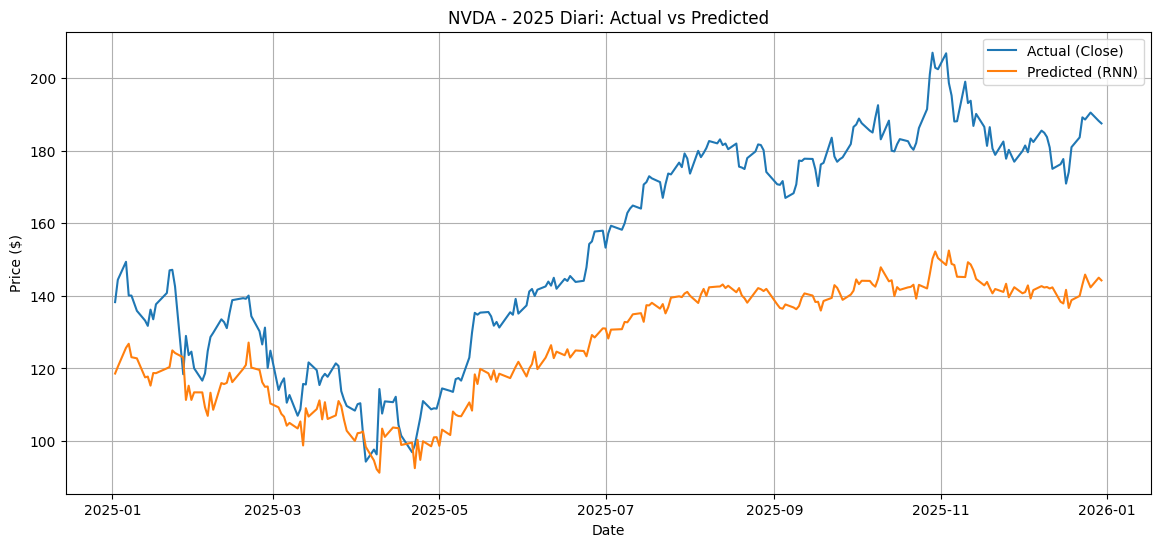

In [ ]:
# -------------------------
# Plot dia a dia (dates reals 2025)
# -------------------------
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_true, label="Actual (Close)")
plt.plot(test_dates, y_pred_rnn, label="Predicted (RNN)")
#plt.plot(test_dates, y_pred_lstm, label="Predicted (LSTM)")
#plt.plot(test_dates, y_pred_gru, label="Predicted (GRU)")
plt.title(f"{EMPRESA} - 2025 Diari: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()

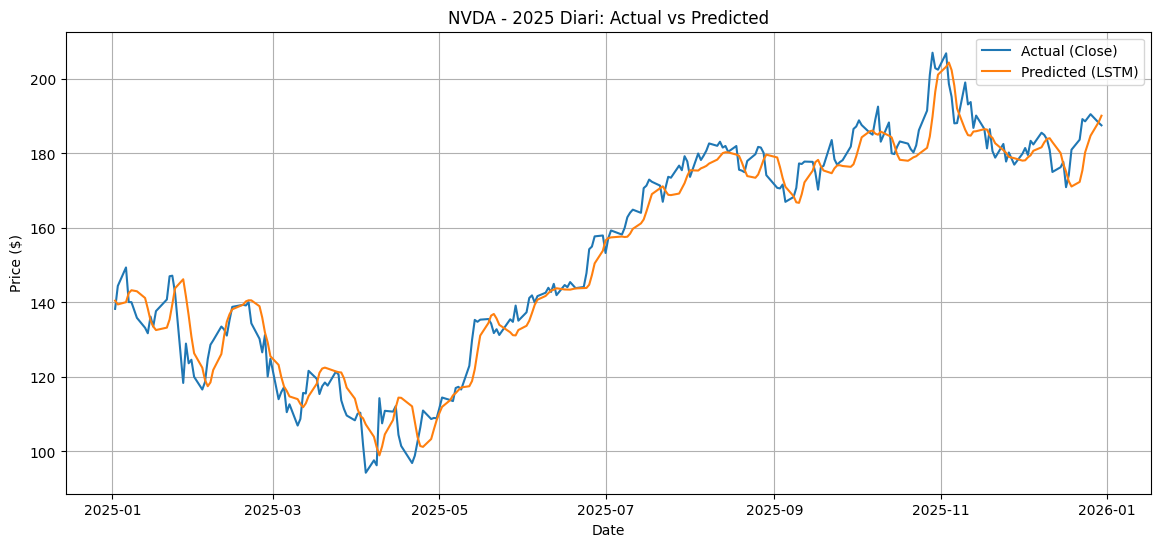

In [ ]:
# -------------------------
# Plot dia a dia (dates reals 2025)
# -------------------------
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_true, label="Actual (Close)")
#plt.plot(test_dates, y_pred_rnn, label="Predicted (RNN)")
plt.plot(test_dates, y_pred_lstm, label="Predicted (LSTM)")
#plt.plot(test_dates, y_pred_gru, label="Predicted (GRU)")
plt.title(f"{EMPRESA} - 2025 Diari: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()

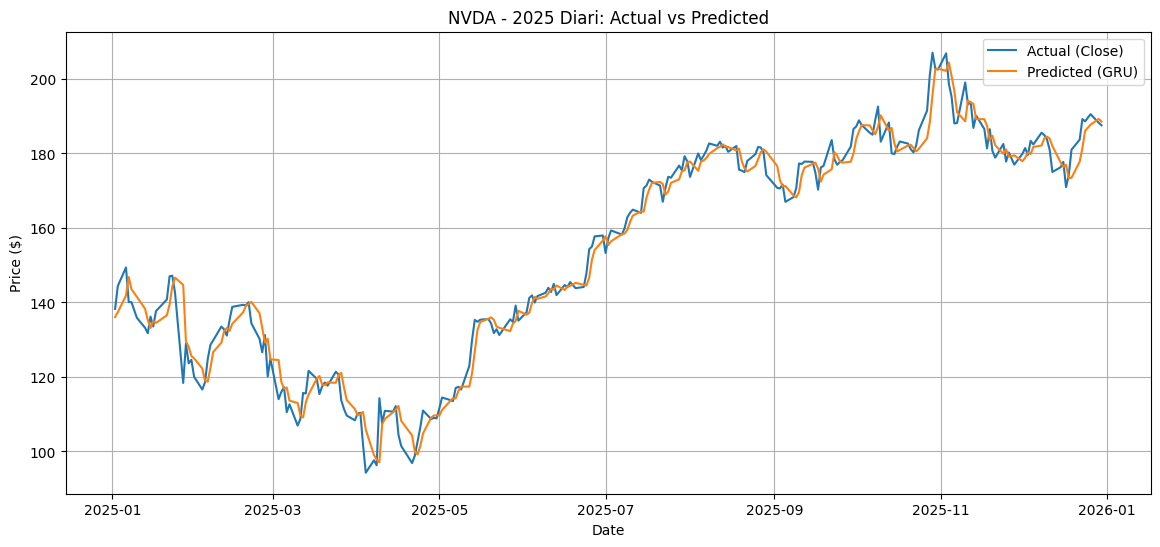

In [ ]:
# -------------------------
# Plot dia a dia (dates reals 2025)
# -------------------------
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_true, label="Actual (Close)")
#plt.plot(test_dates, y_pred_rnn, label="Predicted (RNN)")
#plt.plot(test_dates, y_pred_lstm, label="Predicted (LSTM)")
plt.plot(test_dates, y_pred_gru, label="Predicted (GRU)")
plt.title(f"{EMPRESA} - 2025 Diari: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()